In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('..')

from minilearn.clustering.kmeans import KMeans
from minilearn.decomposition.pca import PCA

os.makedirs('../outputs', exist_ok=True)

X_train_sc = np.load('../outputs/X_train_sc.npy')
X_test_sc  = np.load('../outputs/X_test_sc.npy')
y_train    = np.load('../outputs/y_train.npy')
y_test     = np.load('../outputs/y_test.npy')
feat_cols  = pd.read_csv('../outputs/feature_names.csv').iloc[:, 0].tolist()

# full scaled data for clustering — we cluster everything, not just train
X_all = np.concatenate([X_train_sc, X_test_sc], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

EMOTION_NAMES = {
    1:'neutral', 2:'calm',    3:'happy',    4:'sad',
    5:'angry',   6:'fearful', 7:'disgust',  8:'surprised'
}
LABELS = [EMOTION_NAMES[i] for i in sorted(EMOTION_NAMES.keys())]

print(f'X_all : {X_all.shape}')
print(f'y_all : {y_all.shape}')

X_all : (2452, 112)
y_all : (2452,)


## Why clustering on an already-labelled dataset?

Clustering is unsupervised — it ignores the emotion labels entirely
and finds natural groupings in the audio feature space.

The key question: **do the natural clusters in our feature space
match the human-defined emotion labels?**

If k=8 clusters align well with the 8 emotions → our features
capture genuine acoustic emotion structure.

If clusters don't align → emotions may overlap acoustically,
or our features miss important information.

We evaluate with:
- **ARI (Adjusted Rand Index):** 0=random, 1=perfect match
- **NMI (Normalized Mutual Information):** 0=no info, 1=perfect
- **Visual inspection:** PCA 2D plot, colour by cluster vs emotion

In [6]:
from minilearn.metrics.clustering_metrics import adjusted_rand_index, normalized_mutual_info



In [7]:
# k=8 matches number of emotions
# run multiple times with different seeds — kmeans is sensitive to init
print('Running KMeans k=8...')

best_inertia = np.inf
best_km      = None

for seed in range(5):
    km = KMeans(k=8, max_iter=300, init='kmeans++', random_state=seed)
    km.fit(X_all)
    if km.inertia_ < best_inertia:
        best_inertia = km.inertia_
        best_km      = km

cluster_labels = best_km.labels_

ari = adjusted_rand_index(y_all, cluster_labels)
nmi = normalized_mutual_info(y_all, cluster_labels)

print(f'Inertia : {best_km.inertia_:.2f}')
print(f'ARI     : {ari:.4f}')
print(f'NMI     : {nmi:.4f}')
print(f'Iterations to converge: {best_km.n_iter_}')

Running KMeans k=8...
Inertia : 192471.19
ARI     : 0.0584
NMI     : 0.1188
Iterations to converge: 15


In [8]:
# shows how each cluster maps to emotions
# ideally each cluster is dominated by one emotion

contingency = np.zeros((8, 8), dtype=int)
cls_map     = {c: i for i, c in enumerate(sorted(np.unique(y_all)))}

for true_label, pred_cluster in zip(y_all, cluster_labels):
    contingency[cls_map[true_label], pred_cluster] += 1

cont_df = pd.DataFrame(
    contingency,
    index=LABELS,
    columns=[f'Cluster {i}' for i in range(8)]
)

print('Contingency table (rows=true emotion, cols=cluster):')
print(cont_df.to_string())
print('\nDominant emotion per cluster:')
for col in range(8):
    dominant_idx = contingency[:, col].argmax()
    dominant_pct = contingency[dominant_idx, col] / contingency[:, col].sum() * 100
    print(f'  Cluster {col}: {LABELS[dominant_idx]:10s} ({dominant_pct:.1f}%)')

Contingency table (rows=true emotion, cols=cluster):
           Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5  Cluster 6  Cluster 7
neutral           26         21         43          4          0         20         45         29
calm              45         44         88         11          0         29         96         63
happy             30         17         42         46         83         72         64         22
sad               39         36         76         14         32         48         89         42
angry             17         11         10        110        125         74         16         13
fearful           24         21         39         59         98         58         46         31
disgust           44         26          1          7         17         66          0         31
surprised         45         19          0          2         10         84          0         32

Dominant emotion per cluster:
  Cluster 0: calm       (16.7%)
  

In [9]:
# reduce to 2D so we can visualise clusters
# PCA finds directions of maximum variance

pca_2d = PCA(n_components=2)
X_2d   = pca_2d.fit_transform(X_all)

print(f'Variance explained by 2 components: '
      f'{pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

Variance explained by 2 components: 27.3%


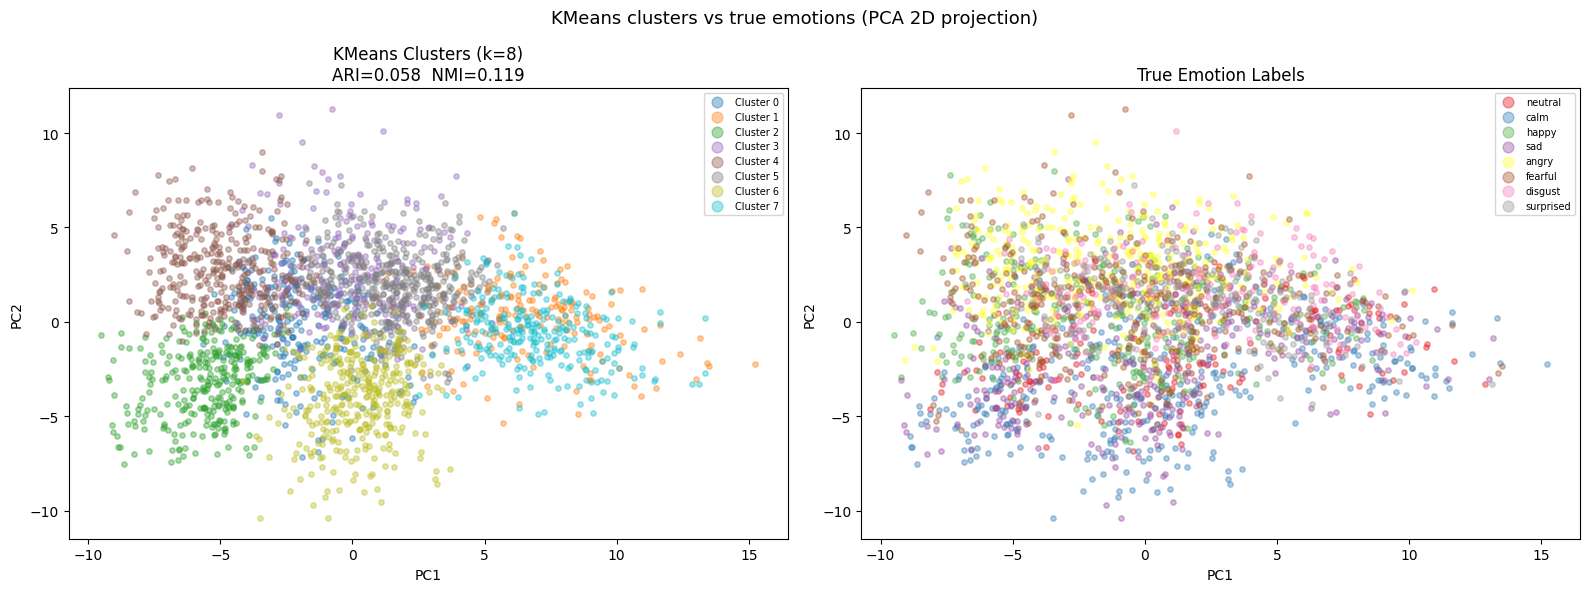

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# colour by cluster assignment
colors_cluster = plt.cm.tab10(np.linspace(0, 1, 8))
for i in range(8):
    mask = cluster_labels == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=[colors_cluster[i]], alpha=0.4, s=15,
                    label=f'Cluster {i}')
axes[0].set_title(f'KMeans Clusters (k=8)\nARI={ari:.3f}  NMI={nmi:.3f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=7, markerscale=2)

# colour by true emotion
colors_emotion = plt.cm.Set1(np.linspace(0, 1, 8))
for i, label in enumerate(LABELS):
    mask = y_all == (i + 1)
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=[colors_emotion[i]], alpha=0.4, s=15,
                    label=label)
axes[1].set_title('True Emotion Labels')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=7, markerscale=2)

plt.suptitle('KMeans clusters vs true emotions (PCA 2D projection)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/kmeans_clusters_vs_emotions.png', dpi=150, bbox_inches='tight')
plt.show()

Computing inertia for k=2 to 14...
  k= 2  inertia=240214.4
  k= 3  inertia=225672.6
  k= 4  inertia=215230.9
  k= 5  inertia=207597.6
  k= 6  inertia=200926.0
  k= 7  inertia=200395.3
  k= 8  inertia=192508.3
  k= 9  inertia=192571.1
  k=10  inertia=189438.5
  k=11  inertia=186073.0
  k=12  inertia=183873.4
  k=13  inertia=182105.4
  k=14  inertia=180217.6


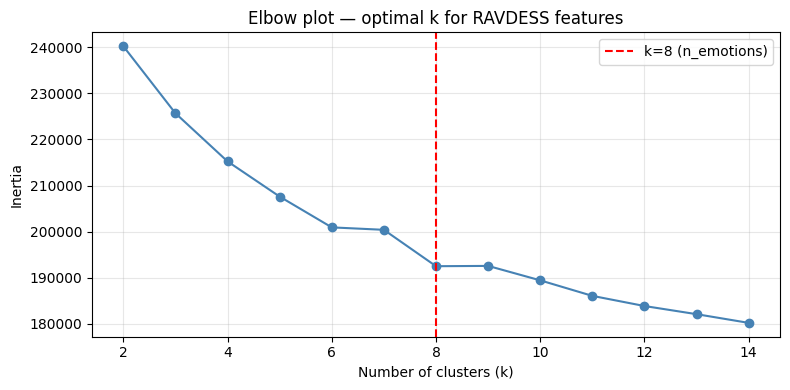

In [11]:
# elbow plot shows optimal k
# where adding more clusters stops reducing inertia significantly

inertias = []
k_range  = range(2, 15)

print('Computing inertia for k=2 to 14...')
for k in k_range:
    km = KMeans(k=k, max_iter=200, init='kmeans++', random_state=42)
    km.fit(X_all)
    inertias.append(km.inertia_)
    print(f'  k={k:2d}  inertia={km.inertia_:.1f}')

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker='o', color='steelblue')
plt.axvline(8, color='red', linestyle='--', label='k=8 (n_emotions)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow plot — optimal k for RAVDESS features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

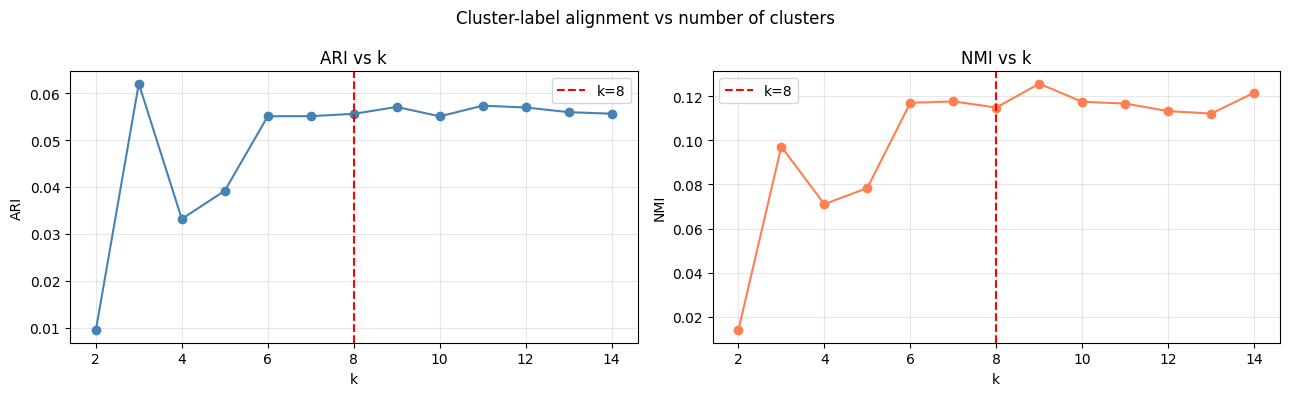

In [12]:
# does k=8 actually give best cluster-label alignment?

ari_scores = []
nmi_scores = []

for k in k_range:
    km = KMeans(k=k, max_iter=200, init='kmeans++', random_state=42)
    km.fit(X_all)
    ari_scores.append(adjusted_rand_index(y_all, km.labels_))
    nmi_scores.append(normalized_mutual_info(y_all, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), ari_scores, marker='o', color='steelblue')
axes[0].axvline(8, color='red', linestyle='--', label='k=8')
axes[0].set_xlabel('k')
axes[0].set_ylabel('ARI')
axes[0].set_title('ARI vs k')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), nmi_scores, marker='o', color='coral')
axes[1].axvline(8, color='red', linestyle='--', label='k=8')
axes[1].set_xlabel('k')
axes[1].set_ylabel('NMI')
axes[1].set_title('NMI vs k')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Cluster-label alignment vs number of clusters', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/kmeans_ari_nmi_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 features varying most across cluster centroids:
  chroma_mean_10             variance=0.7601
  chroma_mean_2              variance=0.7319
  chroma_mean_9              variance=0.7162
  chroma_mean_1              variance=0.7131
  mfcc_mean_5                variance=0.7098
  mfcc_mean_6                variance=0.7015
  chroma_mean_11             variance=0.6965
  chroma_mean_8              variance=0.6814
  chroma_mean_3              variance=0.6738
  mfcc_mean_9                variance=0.6715


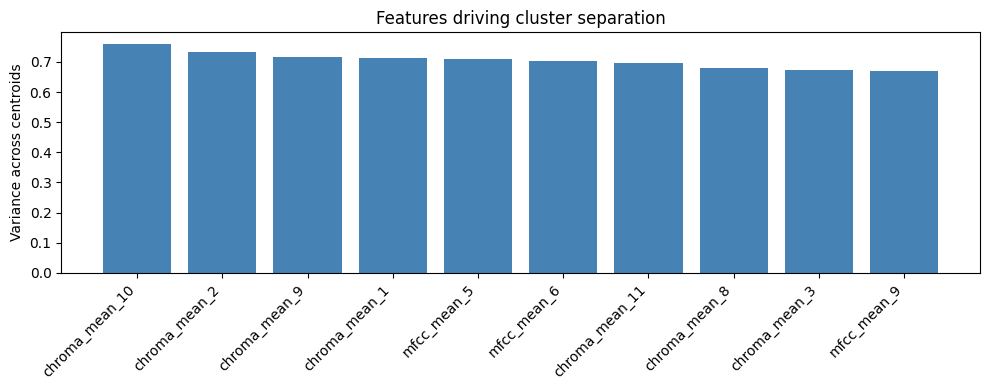

In [13]:
# what does each cluster centroid look like in feature space?
# which features differ most between clusters?

centroids = best_km.centroids_   # shape (8, 112)

# top features that vary most across centroids
centroid_var = np.var(centroids, axis=0)
top_idx      = np.argsort(centroid_var)[::-1][:10]
top_feats    = [feat_cols[i] for i in top_idx]

print('Top 10 features varying most across cluster centroids:')
for feat, var in zip(top_feats, centroid_var[top_idx]):
    print(f'  {feat:25s}  variance={var:.4f}')

plt.figure(figsize=(10, 4))
plt.bar(top_feats, centroid_var[top_idx], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Variance across centroids')
plt.title('Features driving cluster separation')
plt.tight_layout()
plt.savefig('../outputs/kmeans_centroid_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
clustering_results = {
    'k'        : 8,
    'ari'      : ari,
    'nmi'      : nmi,
    'inertia'  : best_km.inertia_,
    'n_iter'   : best_km.n_iter_
}

pd.DataFrame([clustering_results]).to_csv(
    '../outputs/week11_clustering_results.csv', index=False
)

print('Week 11 complete')
print(f'ARI = {ari:.4f}  NMI = {nmi:.4f}')
print('\nKey outputs saved:')
for f in ['kmeans_clusters_vs_emotions.png',
          'kmeans_elbow.png',
          'kmeans_ari_nmi_vs_k.png',
          'kmeans_centroid_features.png',
          'week11_clustering_results.csv']:
    print(f'  ../outputs/{f}')

Week 11 complete
ARI = 0.0584  NMI = 0.1188

Key outputs saved:
  ../outputs/kmeans_clusters_vs_emotions.png
  ../outputs/kmeans_elbow.png
  ../outputs/kmeans_ari_nmi_vs_k.png
  ../outputs/kmeans_centroid_features.png
  ../outputs/week11_clustering_results.csv


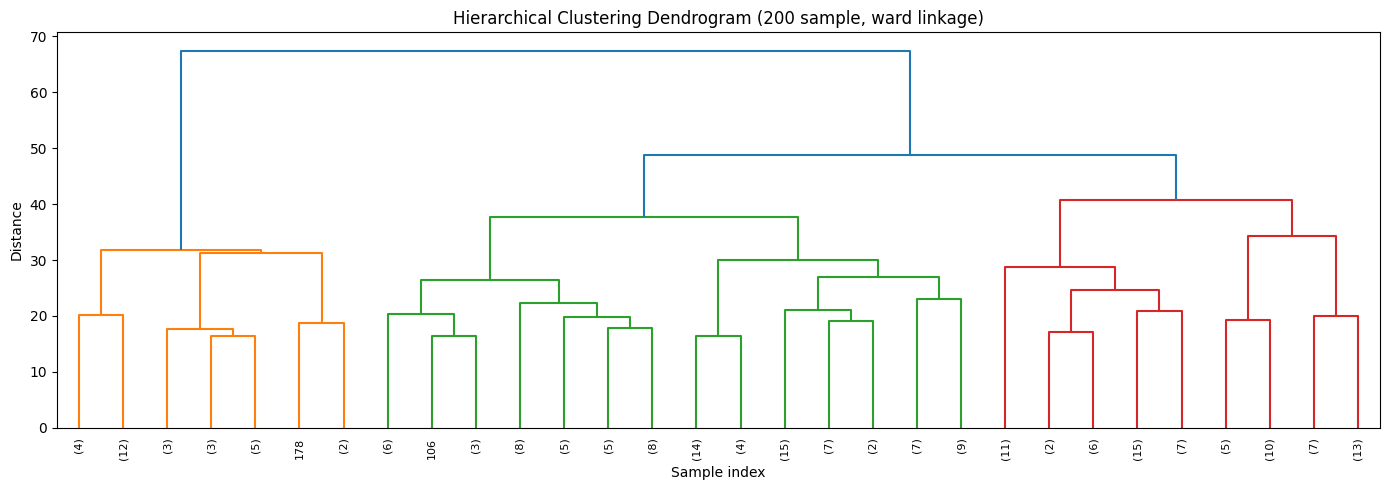

Hierarchical (ward, k=8):
  ARI : 0.0525
  NMI : 0.1563
  vs KMeans ARI=0.0584  NMI=0.1188


In [15]:
# hierarchical clustering — no need to specify k upfront
# builds a tree of merges, cut at any level
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# use ward linkage — minimises variance within clusters
# only run on a sample — full 2452 samples makes dendrogram unreadable
sample_idx = np.random.default_rng(42).choice(len(X_all), size=200, replace=False)
X_sample   = X_all[sample_idx]
y_sample   = y_all[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8)
ax.set_title('Hierarchical Clustering Dendrogram (200 sample, ward linkage)')
ax.set_xlabel('Sample index')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('../outputs/hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# cut tree at k=8 and evaluate
hier_labels = fcluster(Z, t=8, criterion='maxclust')
ari_hier    = adjusted_rand_index(y_sample, hier_labels)
nmi_hier    = normalized_mutual_info(y_sample, hier_labels)

print(f'Hierarchical (ward, k=8):')
print(f'  ARI : {ari_hier:.4f}')
print(f'  NMI : {nmi_hier:.4f}')
print(f'  vs KMeans ARI={ari:.4f}  NMI={nmi:.4f}')

In [16]:
# DBSCAN — density based, finds clusters of arbitrary shape
# does not need k specified — finds it automatically
# points in low-density regions are labelled -1 (noise)
from scipy.spatial.distance import cdist

class DBSCAN:
    """
    DBSCAN from scratch.
    eps     : neighbourhood radius
    min_pts : minimum points to form a core point
    """
    def __init__(self, eps=0.5, min_pts=5):
        self.eps     = eps
        self.min_pts = min_pts

    def fit_predict(self, X):
        n       = len(X)
        labels  = np.full(n, -1)   # -1 = unvisited/noise
        cluster = 0

        # precompute distance matrix — expensive but simple
        dists = cdist(X, X, metric='euclidean')

        def get_neighbours(i):
            return np.where(dists[i] <= self.eps)[0]

        visited = np.zeros(n, dtype=bool)

        for i in range(n):
            if visited[i]:
                continue
            visited[i] = True
            neighbours = get_neighbours(i)

            if len(neighbours) < self.min_pts:
                labels[i] = -1   # noise
            else:
                labels[i] = cluster
                seed_set   = list(neighbours)

                j = 0
                while j < len(seed_set):
                    q = seed_set[j]
                    if not visited[q]:
                        visited[q]   = True
                        q_neighbours = get_neighbours(q)
                        if len(q_neighbours) >= self.min_pts:
                            seed_set.extend(q_neighbours)
                    if labels[q] == -1:
                        labels[q] = cluster
                    j += 1
                cluster += 1

        return labels

# run on PCA-reduced data (faster + better for density estimation)
pca_10    = PCA(n_components=10)
X_pca_10  = pca_10.fit_transform(X_all)

# try different eps values on a sample
sample_idx = np.random.default_rng(42).choice(len(X_pca_10),
                                               size=300, replace=False)
X_db       = X_pca_10[sample_idx]
y_db       = y_all[sample_idx]

print(f'{"eps":>6}  {"n_clusters":>12}  {"noise%":>8}  {"ARI":>8}  {"NMI":>8}')
print('-' * 48)

for eps in [1.0, 2.0, 3.0, 4.0]:
    db      = DBSCAN(eps=eps, min_pts=5)
    db_labs = db.fit_predict(X_db)
    n_clust = len(np.unique(db_labs[db_labs != -1]))
    noise_pct = (db_labs == -1).mean() * 100

    # only evaluate if meaningful clusters found
    if n_clust > 1 and n_clust <= 15:
        valid    = db_labs != -1
        ari_db   = adjusted_rand_index(y_db[valid], db_labs[valid])
        nmi_db   = normalized_mutual_info(y_db[valid], db_labs[valid])
    else:
        ari_db = nmi_db = 0.0

    print(f'{eps:>6}  {n_clust:>12}  {noise_pct:>7.1f}%  {ari_db:>8.4f}  {nmi_db:>8.4f}')

   eps    n_clusters    noise%       ARI       NMI
------------------------------------------------
   1.0             0    100.0%    0.0000    0.0000
   2.0             0    100.0%    0.0000    0.0000
   3.0             1     98.3%    0.0000    0.0000
   4.0             4     66.3%   -0.0115    0.0975
